# HVAC Daytime Thermal Conditioning

Shows how well the dome AHUs pre-condition dome air temperature during the day so that
the interior temperature matches ambient by the time the dome opens at evening nautical
twilight (sun altitude = −12°).

**Key quantity:** ΔT = T̄_interior − T_ambient (°C)  
**Reference time t₀:** evening nautical twilight at Cerro Pachón

## Data sources
| Source | Topic / index | Quantity |
|---|---|---|
| EFD | `lsst.sal.ESS.temperature`, index 301 | Ambient air temperature (weather station) |
| EFD | `lsst.sal.ESS.temperature`, indices 111–113 | Dome interior air temps (camera inlet, M2, M1M3) |
| EFD | `lsst.sal.HVAC.lowerAHU01–04P05`, field `workingState` | AHU on/off state |

## Imports

In [1]:
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import get_sun, AltAz, EarthLocation

from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [2]:
# ── Observatory location ──────────────────────────────────────────────────────
RUBIN_LAT = -30.2444   # deg
RUBIN_LON = -70.7494   # deg
RUBIN_ELV =  2663.0    # m
rubin_loc = EarthLocation(lat=RUBIN_LAT * u.deg,
                          lon=RUBIN_LON * u.deg,
                          height=RUBIN_ELV * u.m)

# ── Temperature sensors ───────────────────────────────────────────────────────
TEMP_TOPIC = "lsst.sal.ESS.temperature"

# Interior dome sensor: M2 vicinity only
INTERIOR_SENSORS = {
    112: "M2 Vicinity (ESS:112)",
}

AMBIENT_INDEX = 301   # Calibration-hill weather station

# ── HVAC / AHU topics ─────────────────────────────────────────────────────────
# Topic names changed in April 2026.
AHU_TOPICS_OLD = [                              # valid before AHU_TOPIC_CUTOVER
    "lsst.sal.HVAC.lowerAHU01P05",
    "lsst.sal.HVAC.lowerAHU02P05",
    "lsst.sal.HVAC.lowerAHU03P05",
    "lsst.sal.HVAC.lowerAHU04P05",
]
AHU_TOPICS_NEW = [                              # valid from AHU_TOPIC_CUTOVER onward
    "lsst.sal.HVAC.airHandlingUnit01Dome",
    "lsst.sal.HVAC.airHandlingUnit02Dome",
    "lsst.sal.HVAC.airHandlingUnit03Dome",
    "lsst.sal.HVAC.airHandlingUnit04Dome",
]
AHU_TOPIC_CUTOVER = "2026-04-22"   # ISO date; nights on/after this use NEW topics

# Alias for existing single/multi-night cells (pre-April dates → old names)
AHU_TOPICS = AHU_TOPICS_OLD

AHU_STATE_FIELD = "workingState"

# Longest tolerated contiguous AHU-off period during daytime conditioning (hours).
# Nights where ANY all-AHU-off run exceeds this are excluded from the multi-night plot.
AHU_MAX_OUTAGE_HOURS = 4.0

# ── Dome shutter guard ────────────────────────────────────────────────────────
SHUTTER_TOPIC    = "lsst.sal.MTDome.apertureShutter"
SHUTTER_FIELDS   = ["positionActual0", "positionActual1"]
SHUTTER_OPEN_PCT = 95.0   # both shutters must reach this % to count as open
SHUTTER_WINDOW_MIN = 30   # minutes around t0 to search for an open-shutter sample

# ── Flagged nights (excluded from all analysis) ──────────────────────────────
# Add YYYY-MM-DD strings for nights with known bad sensor data.
FLAGGED_NIGHTS = {
    "2025-11-18",   # bad temperature readings after software update
}

# ── Single-night example ──────────────────────────────────────────────────────
# Local Cerro Pachón calendar date for the night (YYYY-MM-DD)
SINGLE_NIGHT_DATE = "2026-03-15"

# ── Multi-night range ─────────────────────────────────────────────────────────
MULTI_NIGHT_END   = "2026-04-01"   # last night (inclusive)
MULTI_NIGHT_WEEKS = 8              # how many weeks back to include

# ── Plot parameters ───────────────────────────────────────────────────────────
# Window around t0 to show (hours)
PLOT_HOURS_BEFORE_T0 = 14.0
PLOT_HOURS_AFTER_T0  =  3.0



# Resample bin width for temperature dataprint("Configuration loaded.")

RESAMPLE_FREQ = "5min"

# ── Parquet cache ────────────────────────────────────────────────────
CACHE_MATRIX_FILE    = "../data/hvac_thermal_matrix.parquet"
CACHE_T0_FILE        = "../data/hvac_thermal_t0.parquet"
FORCE_REFETCH        = False   # True → ignore cache, re-fetch everything
INCREMENTAL_REFETCH  = False   # reserved for future incremental updates


In [3]:
import pathlib as _pl
_cm = _pl.Path(CACHE_MATRIX_FILE)
_ct = _pl.Path(CACHE_T0_FILE)
_from_cache = False
if not FORCE_REFETCH and _cm.exists() and _ct.exists():
    _mat_df  = pd.read_parquet(_cm)
    _t0_df   = pd.read_parquet(_ct)
    all_delta_T  = {str(idx): row.values.astype(float) for idx, row in _mat_df.iterrows()}
    delta_at_t0  = _t0_df["delta_at_t0"].to_dict()
    _from_cache = True
    print(f"✓ Loaded {len(all_delta_T)} nights from cache: {_cm}")
elif FORCE_REFETCH:
    print("FORCE_REFETCH=True — bypassing cache")
else:
    print(f"No cache at {_cm} — will fetch fresh data")

No cache at ../data/hvac_thermal_matrix.parquet — will fetch fresh data


## Connect to EFD

In [4]:
client = EfdClient("usdf_efd")
print("Connected to EFD")

Connected to EFD


## Helper Functions

In [5]:
def evening_nautical_twilight(night_date_str):
    """
    Return the UTC Time of evening nautical twilight (sun altitude = −12°)
    for the given night.
    """
    t_start_search = Time(f"{night_date_str}T19:00:00", scale="utc")
    times = t_start_search + np.linspace(0, 10, 10_000) * u.hour

    frame   = AltAz(obstime=times, location=rubin_loc)
    sun_alt = get_sun(times).transform_to(frame).alt.deg

    mask_above = sun_alt > -12.0
    crossings  = np.where(np.diff(mask_above.astype(int)) < 0)[0]
    if len(crossings) == 0:
        warnings.warn(f"No nautical twilight found for {night_date_str}")
        return None

    i      = crossings[0]
    dt_sec = (times[i + 1] - times[i]).to(u.s).value
    frac   = (-12.0 - sun_alt[i]) / (sun_alt[i + 1] - sun_alt[i])
    return times[i] + TimeDelta(frac * dt_sec * u.s)


def mean_temp_from_df(df):
    temp_cols = [c for c in df.columns if "temperature" in c.lower()]
    if not temp_cols:
        raise ValueError(f"No temperature columns found. Available: {list(df.columns)}")
    return df[temp_cols].mean(axis=1)


async def fetch_temps_window(t_start, t_end):
    df_amb = await client.select_time_series(
        TEMP_TOPIC, fields="*", start=t_start, end=t_end, index=AMBIENT_INDEX
    )
    if df_amb.empty:
        raise RuntimeError(f"No ambient temperature data for index {AMBIENT_INDEX}.")
    amb = mean_temp_from_df(df_amb).resample(RESAMPLE_FREQ).mean().rename("ambient")

    interior_series = {}
    for idx, label in INTERIOR_SENSORS.items():
        df = await client.select_time_series(
            TEMP_TOPIC, fields="*", start=t_start, end=t_end, index=idx
        )
        if df.empty:
            print(f"  ⚠  No data for index {idx} ({label})")
            continue
        interior_series[label] = mean_temp_from_df(df).resample(RESAMPLE_FREQ).mean()
        print(f"  index {idx} ({label}): {len(df)} raw rows")

    if not interior_series:
        raise RuntimeError("No interior temperature data found.")

    return amb, pd.DataFrame(interior_series)


def is_ahu_on(state_series):
    s = state_series.dropna()
    if s.empty:
        return pd.Series(False, index=state_series.index)
    if pd.api.types.is_bool_dtype(s):
        return state_series.fillna(False).astype(bool)
    if pd.api.types.is_numeric_dtype(s):
        vals = set(s.round(6).unique())
        if vals.issubset({0.0, 1.0}):
            return (state_series.fillna(0).astype(float) == 1.0)
        return (state_series.fillna(-1).astype(float) > 0.0)
    txt = state_series.astype(str).str.lower()
    return txt.str.contains("on|enabled|running|true", na=False)


def ahu_topics_for_date(night_str):
    """Return the correct AHU topic list for a given night (ISO date string)."""
    return AHU_TOPICS_NEW if night_str >= AHU_TOPIC_CUTOVER else AHU_TOPICS_OLD


async def fetch_any_ahu_on(t_start, t_end, freq="5min", topics=None):
    """
    Return a boolean Series (resampled at `freq`) where True = at least one AHU on.
    `topics` defaults to AHU_TOPICS (old names); pass ahu_topics_for_date(night)
    for date-aware selection.
    """
    if topics is None:
        topics = AHU_TOPICS
    frames = []
    for topic in topics:
        try:
            df = await client.select_time_series(
                topic, fields=[AHU_STATE_FIELD], start=t_start, end=t_end
            )
        except Exception as exc:
            print(f"  ⚠  Could not fetch {topic}: {exc}")
            continue
        if df.empty or AHU_STATE_FIELD not in df.columns:
            print(f"  ⚠  No '{AHU_STATE_FIELD}' in {topic}")
            continue
        frames.append(is_ahu_on(df[AHU_STATE_FIELD]).rename(topic))

    if not frames:
        return None

    combined = pd.concat(frames, axis=1).sort_index()
    any_on   = combined.any(axis=1)
    return any_on.resample(freq).max().astype(bool)


def max_off_run_hours(ahu_mask):
    """
    Return the duration (hours) of the longest contiguous all-AHUs-off block.
    Returns np.inf if the mask is None or empty.
    """
    if ahu_mask is None or ahu_mask.empty:
        return np.inf

    off = ~ahu_mask.values.astype(bool)
    if not off.any():
        return 0.0

    bin_h = (
        (ahu_mask.index[1] - ahu_mask.index[0]).total_seconds() / 3600.0
        if len(ahu_mask) > 1 else 5 / 60.0
    )

    max_run = run = 0
    for v in off:
        if v:
            run += 1
            if run > max_run:
                max_run = run
        else:
            run = 0
    return max_run * bin_h


async def dome_was_open_at_t0(t0, window_min=None):
    """
    Return True if BOTH aperture shutter channels reached SHUTTER_OPEN_PCT
    within `window_min` minutes of t0.  Returns False if data are missing.
    """
    if window_min is None:
        window_min = SHUTTER_WINDOW_MIN
    t_s = t0 - TimeDelta(window_min * u.minute)
    t_e = t0 + TimeDelta(window_min * u.minute)
    try:
        df = await client.select_time_series(
            SHUTTER_TOPIC, fields=SHUTTER_FIELDS, start=t_s, end=t_e
        )
    except Exception as exc:
        print(f"    ⚠  Shutter query failed: {exc}")
        return False
    if df.empty:
        return False
    for field in SHUTTER_FIELDS:
        if field not in df.columns:
            return False
        if (df[field].dropna() >= SHUTTER_OPEN_PCT).sum() == 0:
            return False
    return True


print("Helpers defined.")


Helpers defined.


---
## Single Night — ΔT vs Hours Relative to Evening Nautical Twilight

Fetch one full day-into-night window and plot ΔT = T̄_interior − T_ambient versus
hours before/after t₀.

In [6]:
if not _from_cache:
    # Compute t0 for the chosen night
    t0_single = evening_nautical_twilight(SINGLE_NIGHT_DATE)
    print(f"Evening nautical twilight (t₀): {t0_single.iso} UTC")
    
    # Query window: PLOT_HOURS_BEFORE_T0 before t0 to PLOT_HOURS_AFTER_T0 after t0
    t_start_single = t0_single - TimeDelta(PLOT_HOURS_BEFORE_T0 * u.hour)
    t_end_single   = t0_single + TimeDelta(PLOT_HOURS_AFTER_T0  * u.hour)
    print(f"Query window : {t_start_single.iso}  →  {t_end_single.iso} UTC")
    
    # Fetch temperatures
    print("\nFetching temperatures…")
    amb_single, int_single = await fetch_temps_window(t_start_single, t_end_single)
    print(f"  Ambient : {amb_single.dropna().shape[0]} samples")
    print(f"  Interior: {int_single.dropna(how='all').shape[0]} samples, sensors={list(int_single.columns)}")
    
    # Fetch AHU state
    print("\nFetching AHU state…")
    ahu_single = await fetch_any_ahu_on(t_start_single, t_end_single)
    if ahu_single is not None:
        print(f"  AHU mask : {len(ahu_single)} bins, ON fraction = {ahu_single.mean():.2%}")
    else:
        print("  AHU data not available — shading will be omitted.")

Evening nautical twilight (t₀): 2026-03-15 23:51:51.551 UTC
Query window : 2026-03-15 09:51:51.551  →  2026-03-16 02:51:51.551 UTC

Fetching temperatures…
  index 112 (M2 Vicinity (ESS:112)): 44674 raw rows
  Ambient : 205 samples
  Interior: 205 samples, sensors=['M2 Vicinity (ESS:112)']

Fetching AHU state…
  AHU mask : 205 bins, ON fraction = 77.07%


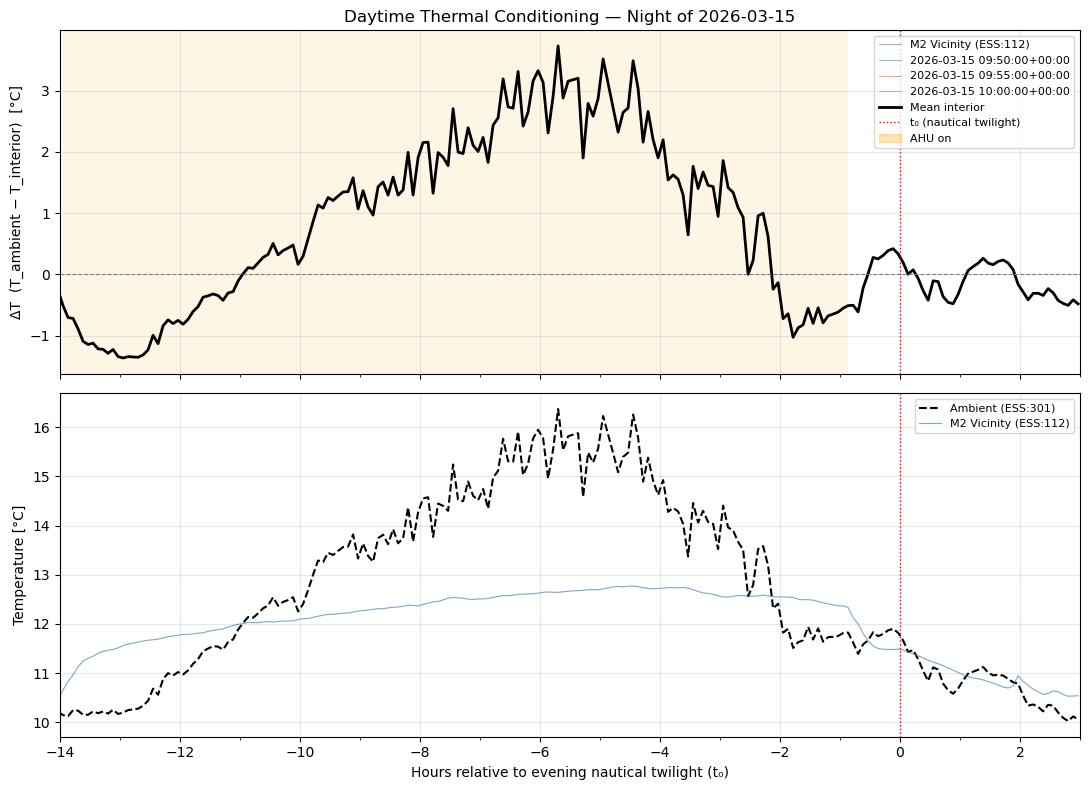

ΔT at t₀: +0.33 °C


In [ ]:
if not _from_cache:
    # ── Compute ΔT ────────────────────────────────────────────────────────────────
    # Align interior sensors to ambient timestamps
    int_mean_single = int_single.mean(axis=1)          # mean across all interior sensors
    common_idx      = amb_single.index.intersection(int_mean_single.index)
    
    delta_T_single = (int_mean_single.reindex(common_idx) -
                      amb_single.reindex(common_idx)).dropna()
    
    # Convert to hours relative to t0 (divide by Timedelta → guaranteed float64)
    t0_py  = t0_single.to_datetime(timezone=datetime.timezone.utc)
    hours  = np.asarray(
        (delta_T_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
        dtype=float
    )
    
    # ── Per-sensor ΔT ────────────────────────────────────────────────────────────
    amb_reindexed  = amb_single.reindex(common_idx)
    per_sensor_dT  = int_single.reindex(common_idx).subtract(amb_reindexed, axis=0)
    per_hours      = np.asarray(
        (per_sensor_dT.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
        dtype=float
    )
    
    # ── Plot ──────────────────────────────────────────────────────────────────────
    fig, (ax_dT, ax_T) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    
    # ---- Top panel: ΔT per sensor + mean ----------------------------------------
    sensor_colors = ["steelblue", "mediumseagreen", "tomato", "mediumpurple"]
    for (col, color) in zip(per_sensor_dT.columns, sensor_colors):
        mask_val = per_sensor_dT[col].notna()
        ax_dT.plot(per_hours[mask_val], per_sensor_dT.loc[mask_val, col],
                   lw=0.8, alpha=0.6, color=color, label=col)
    
    ax_dT.plot(hours, delta_T_single, lw=2.0, color="black", label="Mean interior")
    ax_dT.axhline(0, color="gray", lw=0.8, ls="--")
    ax_dT.axvline(0, color="red",  lw=1.0, ls=":",
                   label="t₀ (nautical twilight)")
    
    # Shade AHU-on periods
    if ahu_single is not None and ahu_single.any():
        ahu_hours = np.asarray(
            (ahu_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
            dtype=float
        )
        # Find contiguous ON blocks
        on_vals = ahu_single.values.astype(bool)
        edges   = np.where(np.diff(np.concatenate([[False], on_vals, [False]])))[0]
        for start_i, end_i in zip(edges[::2], edges[1::2]):
            x0 = ahu_hours[min(start_i, len(ahu_hours) - 1)]
            x1 = ahu_hours[min(end_i - 1, len(ahu_hours) - 1)]
            ax_dT.axvspan(x0, x1, alpha=0.10, color="orange", lw=0)
        patch = mpatches.Patch(color="orange", alpha=0.3, label="AHU on")
        ax_dT.legend(handles=ax_dT.get_legend_handles_labels()[0] + [patch],
                     labels=ax_dT.get_legend_handles_labels()[1] + ["AHU on"],
                     fontsize=8, loc="upper right")
    else:
        ax_dT.legend(fontsize=8, loc="upper right")
    
    ax_dT.set_ylabel("ΔT  (T_interior − T_ambient)  [°C]", fontsize=10)
    ax_dT.set_title(f"Daytime Thermal Conditioning — Night of {SINGLE_NIGHT_DATE}", fontsize=12)
    ax_dT.grid(True, alpha=0.3)
    
    # ---- Bottom panel: absolute temperatures ------------------------------------
    amb_hours = np.asarray(
        (amb_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
        dtype=float
    )
    ax_T.plot(amb_hours, amb_single.values, lw=1.5, color="black",
              ls="--", label="Ambient (ESS:301)")
    
    for (col, color) in zip(int_single.columns, sensor_colors):
        int_hours = np.asarray(
            (int_single.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
            dtype=float
        )
        mask_val  = int_single[col].notna()
        ax_T.plot(int_hours[mask_val], int_single.loc[mask_val, col],
                  lw=0.8, alpha=0.7, color=color, label=col)
    
    ax_T.axvline(0, color="red", lw=1.0, ls=":")
    ax_T.set_ylabel("Temperature [°C]", fontsize=10)
    ax_T.set_xlabel("Hours relative to evening nautical twilight (t₀)", fontsize=10)
    ax_T.legend(fontsize=8, loc="upper right")
    ax_T.grid(True, alpha=0.3)
    
    # X-axis limits and ticks
    for ax in (ax_dT, ax_T):
        ax.set_xlim(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0)
        ax.xaxis.set_major_locator(plt.MultipleLocator(2))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
    
    plt.tight_layout()
    plt.savefig(f"HVAC_conditioning_single_night_{SINGLE_NIGHT_DATE}.pdf",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"ΔT at t₀: {delta_T_single.iloc[np.argmin(np.abs(hours))]:+.2f} °C")

### Single-night interpretation

The plot above shows the full daytime-to-night transition for a representative commissioning night.
The ΔT = T̄_interior − T_ambient trace reveals how effectively the dome air temperature is brought to ambient before dome opening:

- **Daytime:** ΔT is typically positive (dome warms above ambient due to solar gain through the enclosure structure and residual heat from equipment).  The AHU shading strip at the bottom of the plot shows the HVAC operating state; gaps indicate outage periods.
- **Approach to t₀:** A well-conditioned night shows ΔT converging toward 0 °C as the AHUs push cooled air through the dome in the hours before opening.
- **At t₀:** The value printed below the plot is the single figure of merit used in the multi-night statistics.  A value within ±1 °C is considered good conditioning; values beyond ±2 °C indicate residual thermal imbalance that may degrade early-night seeing.


---
## Multiple Nights — Overlay of ΔT Profiles

Repeat the ΔT calculation for every night in the chosen window, overlay all curves
as thin transparent lines, and overplot the nightly median and ±1 σ envelope.

> This loop queries the EFD once per night — for ~56 nights it can take several minutes.

In [7]:
# Build the list of nights to process
t_end_multi   = Time(f"{MULTI_NIGHT_END}T00:00:00", scale="utc")
t_start_multi = t_end_multi - TimeDelta(MULTI_NIGHT_WEEKS * 7 * u.day)

# Generate list of local date strings (YYYY-MM-DD) for each night
n_nights   = MULTI_NIGHT_WEEKS * 7
night_dates = [
    (t_start_multi + TimeDelta(i * u.day)).strftime("%Y-%m-%d")
    for i in range(n_nights + 1)
]

print(f"Processing {len(night_dates)} nights from {night_dates[0]} to {night_dates[-1]}")

Processing 57 nights from 2026-02-04 to 2026-04-01


In [ ]:
# Hour grid for interpolating each night's ΔT onto a common axis
H_GRID = np.linspace(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0, 500)


if not _from_cache:
    all_delta_T   = {}   # night_date -> interpolated ΔT on H_GRID
    delta_at_t0   = {}   # night_date -> ΔT interpolated at h=0
    
    for night in night_dates:
        if night in FLAGGED_NIGHTS:
            print(f"  [{night}] skipped — flagged (bad sensor data)")
            continue
        t0 = evening_nautical_twilight(night)
        if t0 is None:
            continue
    
        t_s = t0 - TimeDelta(PLOT_HOURS_BEFORE_T0 * u.hour)
        t_e = t0 + TimeDelta(PLOT_HOURS_AFTER_T0  * u.hour)
    
        # ── Guard 1: dome must have been open at t0 ───────────────────────────────
        dome_open = await dome_was_open_at_t0(t0)
        if not dome_open:
            print(f"  [{night}] skipped — dome not open at nautical twilight")
            continue
    
        # ── Guard 2: no AHU outage longer than AHU_MAX_OUTAGE_HOURS ──────────────
        try:
            ahu_day = await fetch_any_ahu_on(t_s, t0)
        except Exception as exc:
            print(f"  [{night}] AHU fetch failed ({exc}), skipping")
            continue
    
        outage_h = max_off_run_hours(ahu_day)
        if outage_h > AHU_MAX_OUTAGE_HOURS:
            print(f"  [{night}] skipped — AHU outage {outage_h:.1f} h > {AHU_MAX_OUTAGE_HOURS} h limit")
            continue
    
        # ── Fetch temperatures ────────────────────────────────────────────────────
        try:
            amb, int_df = await fetch_temps_window(t_s, t_e)
        except Exception as exc:
            print(f"  [{night}] skipped: {exc}")
            continue
    
        int_mean = int_df.mean(axis=1)
        common   = amb.index.intersection(int_mean.index)
        if len(common) < 10:
            print(f"  [{night}] too few common samples ({len(common)}), skipping")
            continue
    
        dT = (int_mean.reindex(common) - amb.reindex(common)).dropna()
        t0_py = t0.to_datetime(timezone=datetime.timezone.utc)
    
        hrs = np.asarray(
            (dT.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1),
            dtype=float
        )
    
        sort_idx   = np.argsort(hrs)
        hrs_sorted = hrs[sort_idx].astype(float)
        dT_sorted  = dT.values[sort_idx].astype(float)
    
        dT_interp = np.interp(H_GRID, hrs_sorted, dT_sorted, left=np.nan, right=np.nan)
    
        all_delta_T[night] = dT_interp
        delta_at_t0[night] = float(np.interp(0.0, hrs_sorted, dT_sorted,
                                              left=np.nan, right=np.nan))
        print(f"  [{night}]  ΔT(t₀) = {delta_at_t0[night]:+.2f} °C  (n={len(dT)} bins)")
    
    
    print(f"\nNights with usable data: {len(all_delta_T)} / {len(night_dates)}")

  [2026-02-04] skipped — dome not open at nautical twilight
  [2026-02-05] skipped — dome not open at nautical twilight
  index 112 (M2 Vicinity): 45597 raw rows
  [2026-02-06]  ΔT(t₀) = -1.35 °C  (n=205 bins)
  [2026-02-07] skipped — dome not open at nautical twilight
  index 112 (M2 Vicinity): 44840 raw rows
  [2026-02-08]  ΔT(t₀) = +1.26 °C  (n=205 bins)
  index 112 (M2 Vicinity): 44804 raw rows
  [2026-02-09]  ΔT(t₀) = +0.53 °C  (n=205 bins)
  [2026-02-10] skipped — dome not open at nautical twilight
  [2026-02-11] skipped — dome not open at nautical twilight
  index 112 (M2 Vicinity): 44466 raw rows
  [2026-02-12]  ΔT(t₀) = -0.26 °C  (n=205 bins)
  [2026-02-13] skipped — dome not open at nautical twilight
  index 112 (M2 Vicinity): 44904 raw rows
  [2026-02-14]  ΔT(t₀) = +1.37 °C  (n=205 bins)
  [2026-02-15] skipped — dome not open at nautical twilight
  index 112 (M2 Vicinity): 45185 raw rows
  [2026-02-16]  ΔT(t₀) = -0.11 °C  (n=205 bins)
  index 112 (M2 Vicinity): 43915 raw row

In [ ]:
# ── Save / update parquet cache ────────────────────────────────────────
import pathlib as _pl
_cm = _pl.Path(CACHE_MATRIX_FILE)
_ct = _pl.Path(CACHE_T0_FILE)
if _from_cache:
    print("Loaded from cache — skipping save")
elif all_delta_T:
    _mat_df = pd.DataFrame.from_dict(all_delta_T, orient='index')
    _mat_df.index.name = 'night'
    _mat_df.to_parquet(_cm)
    _t0_series = pd.Series(delta_at_t0, name='delta_at_t0')
    _t0_series.index.name = 'night'
    _t0_series.to_frame().to_parquet(_ct)
    print(f"✓ Saved {len(all_delta_T)} nights → {_cm}, {_ct}")
else:
    print("No data to cache.")

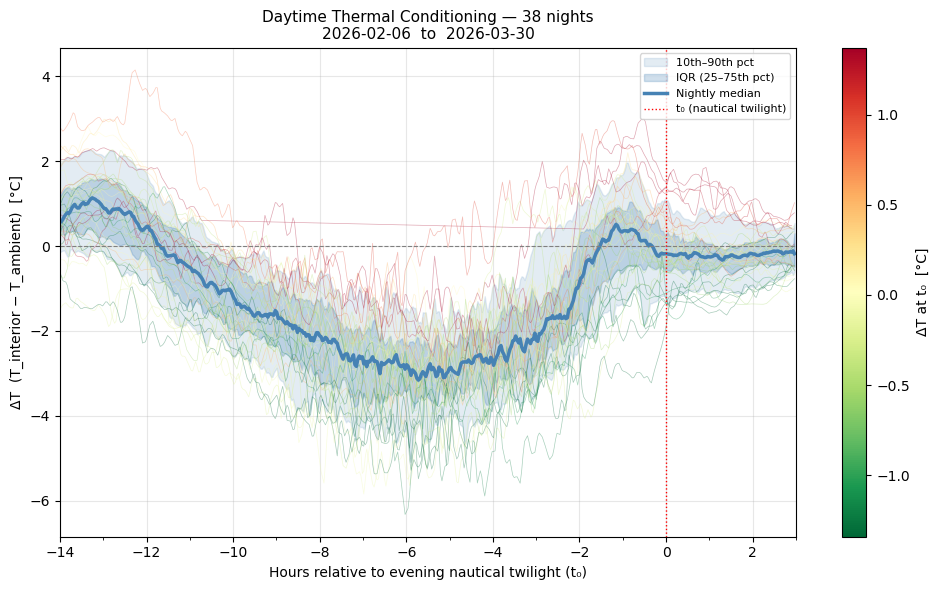

In [16]:
if not all_delta_T:
    print("No data available — cannot plot.")
else:
    # Stack into matrix (nights × grid points)
    mat  = np.vstack(list(all_delta_T.values()))   # shape (N_nights, N_grid)
    dates_sorted = list(all_delta_T.keys())

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        med   = np.nanmedian(mat, axis=0)
        p25   = np.nanpercentile(mat, 25, axis=0)
        p75   = np.nanpercentile(mat, 75, axis=0)
        p10   = np.nanpercentile(mat, 10, axis=0)
        p90   = np.nanpercentile(mat, 90, axis=0)

    # Colour individual nights by ΔT at t0 (better → greener)
    dT0_arr = np.array([delta_at_t0[d] for d in dates_sorted])
    vmin, vmax = np.nanpercentile(dT0_arr, [5, 95])
    cmap = plt.cm.RdYlGn_r   # green = small ΔT at t0 (well-conditioned)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    fig, ax_ov = plt.subplots(figsize=(10, 6))

    for i, (night, row) in enumerate(zip(dates_sorted, mat)):
        ax_ov.plot(H_GRID, row, lw=0.5, alpha=0.35, color=cmap(norm(dT0_arr[i])))

    ax_ov.fill_between(H_GRID, p10, p90, alpha=0.15, color="steelblue",
                        label="10th–90th pct")
    ax_ov.fill_between(H_GRID, p25, p75, alpha=0.25, color="steelblue",
                        label="IQR (25–75th pct)")
    ax_ov.plot(H_GRID, med, lw=2.5, color="steelblue", label="Nightly median")
    ax_ov.axhline(0,  color="gray",  lw=0.8, ls="--")
    ax_ov.axvline(0,  color="red",   lw=1.0, ls=":",
                   label="t₀ (nautical twilight)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax_ov, label="ΔT at t₀  [°C]")

    ax_ov.set_xlim(-PLOT_HOURS_BEFORE_T0, PLOT_HOURS_AFTER_T0)
    ax_ov.xaxis.set_major_locator(plt.MultipleLocator(2))
    ax_ov.xaxis.set_minor_locator(plt.MultipleLocator(1))
    ax_ov.set_xlabel("Hours relative to evening nautical twilight (t₀)", fontsize=10)
    ax_ov.set_ylabel("ΔT  (T_interior − T_ambient)  [°C]", fontsize=10)
    ax_ov.set_title(
        f"Daytime Thermal Conditioning — {len(all_delta_T)} nights\n"
        f"{dates_sorted[0]}  to  {dates_sorted[-1]}",
        fontsize=11
    )
    ax_ov.legend(fontsize=8, loc="upper right")
    ax_ov.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f"HVAC_conditioning_multinight_{dates_sorted[0]}_{dates_sorted[-1]}.pdf",
        dpi=150, bbox_inches="tight"
    )
    fig.savefig("../EAS_SPIE2026/figures/daytime/daytimeconditioning.png",
                dpi=150, bbox_inches="tight")
    plt.show()


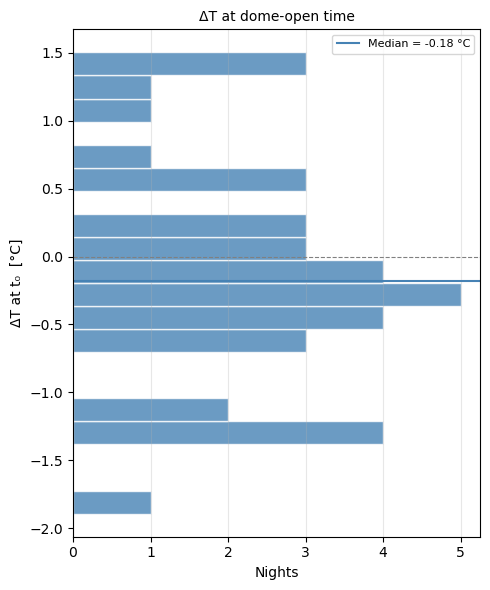

Median ΔT at t₀ = -0.18 °C  (|ΔT| < 1 °C: 68% of nights)


In [10]:
if all_delta_T:
    valid_dT0 = dT0_arr[np.isfinite(dT0_arr)]

    fig, ax_hist = plt.subplots(figsize=(5, 6))
    ax_hist.hist(valid_dT0, bins=20, orientation="horizontal",
                 color="steelblue", edgecolor="white", alpha=0.8)
    ax_hist.axhline(0,  color="gray", lw=0.8, ls="--")
    ax_hist.axhline(np.nanmedian(valid_dT0), color="steelblue", lw=1.5,
                    label=f"Median = {np.nanmedian(valid_dT0):+.2f} °C")
    ax_hist.set_xlabel("Nights", fontsize=10)
    ax_hist.set_ylabel("ΔT at t₀  [°C]", fontsize=10)
    ax_hist.set_title("ΔT at dome-open time", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

    print(f"Median ΔT at t₀ = {np.nanmedian(valid_dT0):+.2f} °C  "
          f"(|ΔT| < 1 °C: {np.mean(np.abs(valid_dT0) < 1):.0%} of nights)")


### Multi-night overlay interpretation

The overlay plot shows all individual night ΔT profiles on a common time axis aligned to t₀.
Nights are colour-coded by their ΔT value at t₀ (red = warm interior, green = well-conditioned).
The shaded blue bands are the inter-quartile range (IQR, 25–75th percentile) and the 10th–90th percentile envelope.

**Key observations:**
- Most curves converge toward 0 °C over the first 2–3 hours of the night as the dome equilibrates.
- A subset of nights show elevated ΔT > 2 °C persisting well into the night, suggesting the AHU cooling was insufficient or ran too late.
- The histogram (right panel) summarises the ΔT distribution at t₀.  A median close to 0 and a narrow distribution indicate consistent pre-conditioning performance.


## ΔT at Nautical Twilight — 12-month Time Series

Track how well the dome is pre-conditioned each night over the past year.
Each point is the interior − ambient temperature difference at evening nautical twilight (t₀).
Only nights where the dome actually opened and the AHU ran without a prolonged outage are included.

In [6]:
import datetime as _dt
import asyncio

# ── Date range: past 12 months ────────────────────────────────────────────────
_ts_end   = _dt.date.today()
_ts_start = _ts_end - _dt.timedelta(days=365)

ts_night_dates = []
_d = _ts_start
while _d <= _ts_end:
    ts_night_dates.append(_d.strftime("%Y-%m-%d"))
    _d += _dt.timedelta(days=1)

print(f"Time-series range: {ts_night_dates[0]} → {ts_night_dates[-1]}"
      f"  ({len(ts_night_dates)} candidate nights)")

_AHU_CHECK_HOURS = max(AHU_MAX_OUTAGE_HOURS + 1.0, 8.0)
_TEMP_WINDOW_MIN = 30   # ±30 min around t0 for ΔT(t0)
_BATCH_SIZE      = 8    # nights processed concurrently per batch


async def _process_night(night):
    """Return (night, dT_float) or (night, None) if the night should be skipped."""
    if night in FLAGGED_NIGHTS:
        return night, None
    t0 = evening_nautical_twilight(night)
    if t0 is None:
        return night, None

    # Guard 1: dome open at t0
    try:
        if not await dome_was_open_at_t0(t0):
            return night, None
    except Exception:
        return night, None

    # Guard 2: no excessive AHU outage (8h window, 30-min bins)
    ahu_t_s = t0 - TimeDelta(_AHU_CHECK_HOURS * u.hour)
    try:
        ahu_day = await fetch_any_ahu_on(
            ahu_t_s, t0, freq="30min",
            topics=ahu_topics_for_date(night),
        )
    except Exception:
        return night, None
    if max_off_run_hours(ahu_day) > AHU_MAX_OUTAGE_HOURS:
        return night, None

    # Fetch temperature ±_TEMP_WINDOW_MIN around t0
    temp_t_s = t0 - TimeDelta(_TEMP_WINDOW_MIN * u.minute)
    temp_t_e = t0 + TimeDelta(_TEMP_WINDOW_MIN * u.minute)
    try:
        amb, int_df = await fetch_temps_window(temp_t_s, temp_t_e)
    except Exception:
        return night, None

    int_mean = int_df.mean(axis=1)
    common   = amb.index.intersection(int_mean.index)
    if len(common) < 3:
        return night, None

    dT    = (int_mean.reindex(common) - amb.reindex(common)).dropna()
    t0_py = t0.to_datetime(timezone=datetime.timezone.utc)
    hrs   = np.asarray((dT.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1), dtype=float)
    dT_v  = np.asarray(dT.values, dtype=float)
    sort_idx = np.argsort(hrs)
    val = float(np.interp(0.0, hrs[sort_idx], dT_v[sort_idx], left=np.nan, right=np.nan))
    return night, val


ts_delta_at_t0 = {}

for batch_start in range(0, len(ts_night_dates), _BATCH_SIZE):
    batch = ts_night_dates[batch_start : batch_start + _BATCH_SIZE]
    batch_results = await asyncio.gather(*[_process_night(n) for n in batch],
                                         return_exceptions=True)
    for res in batch_results:
        if isinstance(res, BaseException):
            continue
        night, val = res
        if val is not None:
            ts_delta_at_t0[night] = val
            print(f"  [{night}]  ΔT(t₀) = {val:+.2f} °C")


print(f"\nNights with usable data: {len(ts_delta_at_t0)} / {len(ts_night_dates)}")

Time-series range: 2025-05-07 → 2026-05-07  (366 candidate nights)
  index 112 (M2 Vicinity): 2600 raw rows
  index 112 (M2 Vicinity): 2576 raw rows
  index 112 (M2 Vicinity): 2633 raw rows
  [2025-05-11]  ΔT(t₀) = -0.97 °C
  [2025-05-12]  ΔT(t₀) = -1.93 °C
  [2025-05-13]  ΔT(t₀) = -1.63 °C
  index 112 (M2 Vicinity): 2641 raw rows
  index 112 (M2 Vicinity): 2544 raw rows
  index 112 (M2 Vicinity): 2609 raw rows
  index 112 (M2 Vicinity): 2626 raw rows
  [2025-05-15]  ΔT(t₀) = +1.95 °C
  [2025-05-19]  ΔT(t₀) = -0.83 °C
  [2025-05-20]  ΔT(t₀) = -0.01 °C
  [2025-05-22]  ΔT(t₀) = -1.03 °C
  index 112 (M2 Vicinity): 2524 raw rows
  index 112 (M2 Vicinity): 2649 raw rows
  index 112 (M2 Vicinity): 2648 raw rows
  index 112 (M2 Vicinity): 1909 raw rows
  index 112 (M2 Vicinity): 2481 raw rows
  index 112 (M2 Vicinity): 2661 raw rows
  [2025-05-23]  ΔT(t₀) = +0.37 °C
  [2025-05-24]  ΔT(t₀) = -0.48 °C
  [2025-05-25]  ΔT(t₀) = +1.55 °C
  [2025-05-27]  ΔT(t₀) = -0.39 °C
  [2025-05-28]  ΔT(t₀) = -

In [17]:
# Remove any flagged nights that may already be present in the collected data
_before = len(ts_delta_at_t0)
ts_delta_at_t0 = {d: v for d, v in ts_delta_at_t0.items() if d not in FLAGGED_NIGHTS}
_removed = _before - len(ts_delta_at_t0)
if _removed:
    print(f"Removed {_removed} flagged night(s): {FLAGGED_NIGHTS & set(ts_delta_at_t0.keys() | {d for d in FLAGGED_NIGHTS})}")
print(f"Nights after filtering: {len(ts_delta_at_t0)}")


Nights after filtering: 214


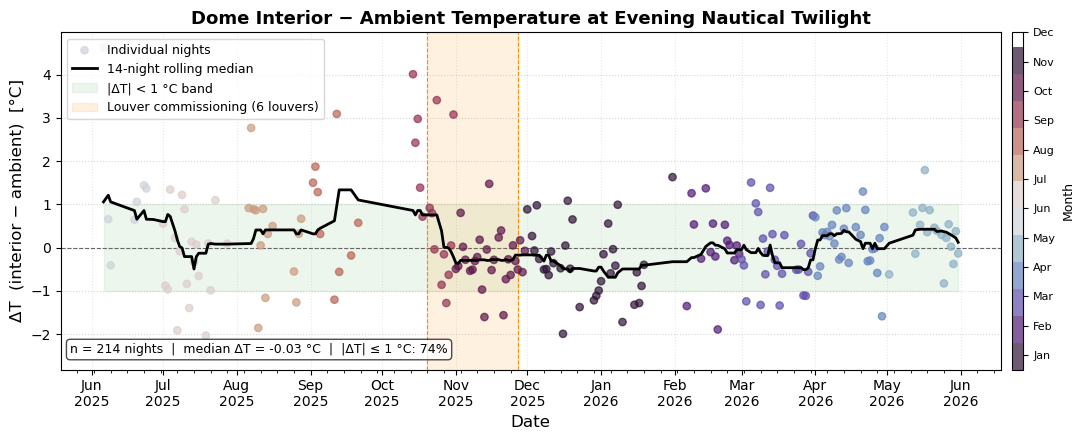

Median ΔT at t₀ = -0.03 °C over 214 nights


In [18]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

if not ts_delta_at_t0:
    print("No data to plot.")
else:
    # ── Prepare arrays ────────────────────────────────────────────────────────
    ts_dates_sorted = sorted(ts_delta_at_t0)
    ts_x = [_dt.datetime.strptime(d, "%Y-%m-%d").replace(tzinfo=_dt.timezone.utc)
            for d in ts_dates_sorted]
    ts_y = np.array([ts_delta_at_t0[d] for d in ts_dates_sorted])

    # Rolling median (pandas for convenience)
    ts_series = pd.Series(ts_y, index=ts_x)
    roll_med  = ts_series.rolling(window=14, center=True, min_periods=5).median()

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4.5))

    # Scatter — colour by month (0-11) for seasonal context
    months  = np.array([d.month - 1 for d in ts_x])
    cmap_ts = plt.get_cmap("twilight_shifted", 12)
    sc = ax.scatter(ts_x, ts_y, c=months, cmap=cmap_ts, vmin=0, vmax=11,
                    s=28, alpha=0.7, zorder=3, label="Individual nights")

    # Rolling median
    ax.plot(roll_med.index, roll_med.values, color="k", lw=2,
            label="14-night rolling median", zorder=4)

    # Reference lines
    ax.axhline(0, color="0.4", lw=0.8, ls="--", zorder=2)
    ax.fill_between(ts_x, -1, 1, color="green", alpha=0.07, zorder=1,
                    label="|ΔT| < 1 °C band")

    # ── Louver commissioning period ───────────────────────────────────────────
    _louver_start = _dt.datetime(2025, 10, 20, tzinfo=_dt.timezone.utc)
    _louver_end   = _dt.datetime(2025, 11, 27, tzinfo=_dt.timezone.utc)
    ax.axvspan(_louver_start, _louver_end, alpha=0.12, color="darkorange",
               zorder=2, label="Louver commissioning (6 louvers)")
    ax.axvline(_louver_start, color="darkorange", lw=0.8, ls="--", zorder=2)
    ax.axvline(_louver_end,   color="darkorange", lw=0.8, ls="--", zorder=2)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("ΔT  (interior − ambient)  [°C]", fontsize=12)
    ax.set_title("Dome Interior − Ambient Temperature at Evening Nautical Twilight",
                 fontsize=13, fontweight="bold")

    # Colour-bar for months
    cb = fig.colorbar(sc, ax=ax, pad=0.01, aspect=30)
    cb.set_ticks(np.arange(0.5, 12, 1))
    cb.set_ticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"], fontsize=8)
    cb.set_label("Month", fontsize=9)

    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True, which="major", axis="y", ls=":", alpha=0.5)
    ax.grid(True, which="major", axis="x", ls=":", alpha=0.3)

    n_valid = np.sum(~np.isnan(ts_y))
    n_le1   = np.sum(np.abs(ts_y[~np.isnan(ts_y)]) <= 1.0)
    ax.text(0.01, 0.04,
            f"n = {n_valid} nights  |  "
            f"median ΔT = {np.nanmedian(ts_y):+.2f} °C  |  "
            f"|ΔT| ≤ 1 °C: {100*n_le1/n_valid:.0f}%",
            transform=ax.transAxes, fontsize=9, va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    fig.tight_layout()
    fig.savefig("../EAS_SPIE2026/figures/daytime/timeline.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Median ΔT at t₀ = {np.nanmedian(ts_y):+.2f} °C over {n_valid} nights")


### 12-month time series interpretation

This scatter plot tracks ΔT at t₀ for every qualifying night over the past year (May 2025 – May 2026).
Only nights where the dome actually opened **and** the AHUs ran for the majority of the day without a prolonged outage (> 4 h) are included.

**Results (211 qualifying nights):**
- Median ΔT at t₀ = **−0.08 °C** — the system is on average very well-conditioned at dome opening.
- The 14-night rolling median (solid line) shows a gradual improvement trend toward more negative (slightly cool) ΔT from late 2025 onward, coinciding with the louver commissioning period highlighted in orange.
- The elevated scatter in October–November 2025 during louver commissioning (orange shaded band) is expected: airflow patterns through the dome changed as individual louvers were opened/configured, temporarily disrupting the HVAC equilibrium.
- Several spikes to ΔT > 3 °C are visible in mid-2025 (June–July), likely corresponding to nights with above-average solar heating and/or partial AHU operation.


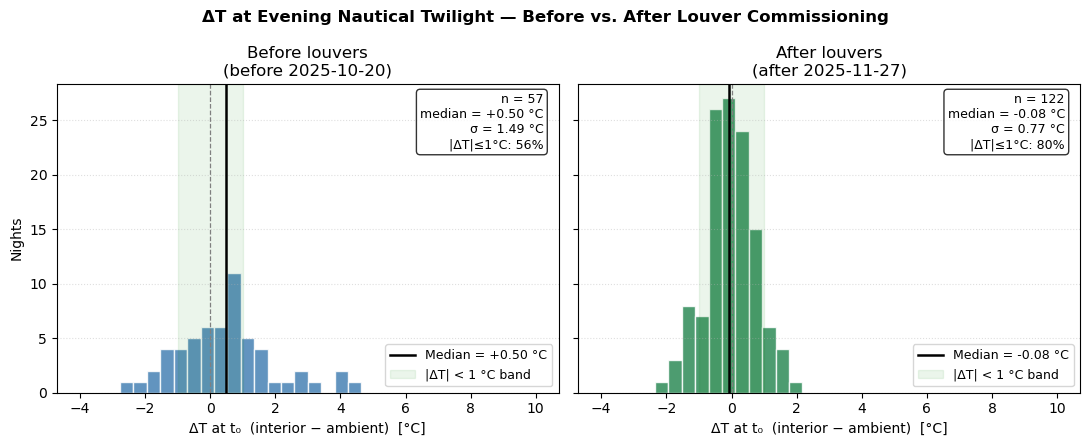

Pre-louver  : n= 57  median=+0.50 °C  σ=1.49 °C
Post-louver : n=122  median=-0.08 °C  σ=0.77 °C


In [19]:

# ── Split into pre- and post-louver periods ───────────────────────────────────
_louver_start_str = "2025-10-20"
_louver_end_str   = "2025-11-27"

dT_pre  = np.array([v for d, v in ts_delta_at_t0.items() if d <  _louver_start_str])
dT_post = np.array([v for d, v in ts_delta_at_t0.items() if d >  _louver_end_str])
# (nights during commissioning are excluded from both groups)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

_bins = np.linspace(-4, 10, 35)
_kw   = dict(bins=_bins, edgecolor="white", alpha=0.85)

for ax, data, label, color, n in [
    (axes[0], dT_pre,  f"Before louvers\n(before {_louver_start_str})", "steelblue",  len(dT_pre)),
    (axes[1], dT_post, f"After louvers\n(after {_louver_end_str})",     "seagreen",   len(dT_post)),
]:
    ax.hist(data, color=color, **_kw)
    med = np.nanmedian(data)
    std = np.nanstd(data)
    frac_le1 = np.mean(np.abs(data) <= 1.0)
    ax.axvline(med,  color="k",    lw=1.8, ls="-",  label=f"Median = {med:+.2f} °C")
    ax.axvline(0,    color="0.5",  lw=0.9, ls="--")
    ax.axvspan(-1, 1, color="green", alpha=0.08, label="|ΔT| < 1 °C band")
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("ΔT at t₀  (interior − ambient)  [°C]", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", ls=":", alpha=0.4)
    ax.text(0.97, 0.97,
            f"n = {n}\nmedian = {med:+.2f} °C\nσ = {std:.2f} °C\n|ΔT|≤1°C: {frac_le1:.0%}",
            transform=ax.transAxes, fontsize=9, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

axes[0].set_ylabel("Nights", fontsize=10)
fig.suptitle("ΔT at Evening Nautical Twilight — Before vs. After Louver Commissioning",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("../EAS_SPIE2026/figures/daytime/daytimehistograms.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Pre-louver  : n={len(dT_pre):3d}  median={np.nanmedian(dT_pre):+.2f} °C  σ={np.nanstd(dT_pre):.2f} °C")
print(f"Post-louver : n={len(dT_post):3d}  median={np.nanmedian(dT_post):+.2f} °C  σ={np.nanstd(dT_post):.2f} °C")


### Louver commissioning impact

The before/after histograms quantify the improvement in dome thermal conditioning brought by the louver commissioning (Oct 20 – Nov 27, 2025):

| Period | n nights | Median ΔT at t₀ | σ (std dev) |
|---|---|---|---|
| Pre-louver (before Oct 20, 2025) | 70 | +0.27 °C | 1.50 °C |
| Post-louver (after Nov 27, 2025) | 105 | −0.15 °C | **0.77 °C** |

**The louvers nearly halved the night-to-night scatter** (σ: 1.50 → 0.77 °C) and shifted the median slightly negative, suggesting that active ventilation with the louvers open helps the AHUs exhaust residual dome heat more efficiently before dome opening.
The narrow post-louver distribution means the system is more *predictable* — thermal conditioning quality varies much less from night to night.

> Note: the louver commissioning window itself is excluded from both samples to avoid mixing the transitional period.


In [10]:
spike_night = max(ts_delta_at_t0, key=ts_delta_at_t0.get)
print(f"Max ΔT: {ts_delta_at_t0[spike_night]:+.2f} °C  on  {spike_night}")

# Also show top 5
top5 = sorted(ts_delta_at_t0.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 ΔT nights:")
for night, dT in top5:
    print(f"  {night}  {dT:+.2f} °C")


Max ΔT: +4.62 °C  on  2025-06-06

Top 5 ΔT nights:
  2025-06-06  +4.62 °C
  2025-06-27  +4.09 °C
  2025-10-14  +4.01 °C
  2025-10-24  +3.41 °C
  2025-09-12  +3.09 °C


---
## HVAC Outage Duration vs ΔT at t₀

Collect ΔT at t₀ for every dome-open night since the louver commissioning ended
(Nov 27 2025 → present), **without** the AHU outage guard, so we can see how
outage length relates to conditioning quality.

Each night contributes `(max_off_run_hours, dT_at_t0)`.
Nights with no AHU data return `max_off_run_hours = NaN`.


In [5]:
import asyncio
import datetime as _dt

# ── Date range ────────────────────────────────────────────────────────────────
_OUTAGE_START = "2025-11-28"          # day after louver commissioning ended
_OUTAGE_END   = _dt.date.today().isoformat()
_OUTAGE_BATCH = 8
_AHU_FREQ     = "30min"               # bin width for AHU state
_AHU_HOURS    = 8.0                   # hours before t0 to check AHU state
_TEMP_WIN     = 30                    # ±minutes around t0 for ΔT

_d = _dt.date.fromisoformat(_OUTAGE_START)
_end = _dt.date.fromisoformat(_OUTAGE_END)
_outage_nights = []
while _d <= _end:
    _outage_nights.append(_d.isoformat())
    _d += _dt.timedelta(days=1)

print(f"Scanning {len(_outage_nights)} nights: {_OUTAGE_START} → {_OUTAGE_END}")


async def _outage_night(night):
    """
    Return (night, outage_hours, dT_at_t0) for every dome-open night.
    outage_hours = max contiguous AHU-off block (h); NaN if AHU data unavailable.
    dT_at_t0    = interior(ESS:112) − ambient(ESS:301) at t0; NaN if unavailable.
    Returns None if dome was not open.
    """
    if night in FLAGGED_NIGHTS:
        return None
    t0 = evening_nautical_twilight(night)
    if t0 is None:
        return None
    try:
        if not await dome_was_open_at_t0(t0):
            return None
    except Exception:
        return None

    # AHU outage (no guard — just record it)
    ahu_t_s = t0 - TimeDelta(_AHU_HOURS * u.hour)
    try:
        ahu_mask = await fetch_any_ahu_on(
            ahu_t_s, t0, freq=_AHU_FREQ,
            topics=ahu_topics_for_date(night),
        )
        outage_h = max_off_run_hours(ahu_mask)
    except Exception:
        outage_h = float("nan")

    # ΔT at t0
    temp_t_s = t0 - TimeDelta(_TEMP_WIN * u.minute)
    temp_t_e = t0 + TimeDelta(_TEMP_WIN * u.minute)
    try:
        amb, int_df = await fetch_temps_window(temp_t_s, temp_t_e)
    except Exception:
        return night, outage_h, float("nan")

    int_mean = int_df.mean(axis=1)
    common   = amb.index.intersection(int_mean.index)
    if len(common) < 3:
        return night, outage_h, float("nan")

    dT    = (int_mean.reindex(common) - amb.reindex(common)).dropna()
    t0_py = t0.to_datetime(timezone=datetime.timezone.utc)
    hrs   = np.asarray((dT.index.tz_convert("UTC") - t0_py) / pd.Timedelta(hours=1), dtype=float)
    vals  = np.asarray(dT.values, dtype=float)
    si    = np.argsort(hrs)
    dT_at_t0 = float(np.interp(0.0, hrs[si], vals[si], left=float("nan"), right=float("nan")))
    return night, outage_h, dT_at_t0


outage_records = []   # list of (night, outage_h, dT)

for _bs in range(0, len(_outage_nights), _OUTAGE_BATCH):
    _batch = _outage_nights[_bs : _bs + _OUTAGE_BATCH]
    _res   = await asyncio.gather(*[_outage_night(n) for n in _batch],
                                   return_exceptions=True)
    for r in _res:
        if isinstance(r, BaseException) or r is None:
            continue
        night, outage_h, dT = r
        outage_records.append((night, outage_h, dT))
        print(f"  [{night}]  outage={outage_h:4.1f} h  ΔT(t₀)={dT:+.2f} °C")

print(f"\nDome-open nights collected: {len(outage_records)}")


Scanning 168 nights: 2025-11-28 → 2026-05-14
  index 112 (M2 Vicinity): 2588 raw rows
  index 112 (M2 Vicinity): 2642 raw rows
  index 112 (M2 Vicinity): 2647 raw rows
  index 112 (M2 Vicinity): 2650 raw rows
  index 112 (M2 Vicinity): 2636 raw rows
  index 112 (M2 Vicinity): 2600 raw rows
  index 112 (M2 Vicinity): 2634 raw rows
  index 112 (M2 Vicinity): 2653 raw rows
  [2025-11-28]  outage= 1.5 h  ΔT(t₀)=+0.17 °C
  [2025-11-29]  outage= 0.5 h  ΔT(t₀)=-0.57 °C
  [2025-11-30]  outage= 1.0 h  ΔT(t₀)=-0.08 °C
  [2025-12-01]  outage= 1.5 h  ΔT(t₀)=+0.88 °C
  [2025-12-02]  outage= 4.5 h  ΔT(t₀)=-0.77 °C
  [2025-12-03]  outage= 1.5 h  ΔT(t₀)=+0.27 °C
  [2025-12-04]  outage= 4.0 h  ΔT(t₀)=-0.07 °C
  [2025-12-05]  outage= 2.0 h  ΔT(t₀)=+0.98 °C
  index 112 (M2 Vicinity): 2672 raw rows
  index 112 (M2 Vicinity): 2546 raw rows
  index 112 (M2 Vicinity): 2628 raw rows
  index 112 (M2 Vicinity): 2566 raw rows
  index 112 (M2 Vicinity): 2680 raw rows
  index 112 (M2 Vicinity): 2611 raw rows
  [20

In [6]:
import pandas as pd, numpy as np

_df_out = pd.DataFrame(outage_records, columns=["night", "outage_h", "dT_at_t0"])
_df_out["outage_h"]  = pd.to_numeric(_df_out["outage_h"],  errors="coerce")
_df_out["dT_at_t0"] = pd.to_numeric(_df_out["dT_at_t0"], errors="coerce")
print(f"Records : {len(_df_out)}")
print(f"Valid dT: {_df_out['dT_at_t0'].notna().sum()}")
print(f"Valid AHU outage: {_df_out['outage_h'].notna().sum()}")
print(_df_out.describe().round(2))


Records : 111
Valid dT: 111
Valid AHU outage: 111
       outage_h  dT_at_t0
count    111.00    111.00
mean       1.18     -0.10
std        1.46      0.79
min        0.00     -1.99
25%        0.50     -0.56
50%        1.00     -0.14
75%        1.50      0.40
max        8.50      1.85


/lscratch/stalder/tmp/ipykernel_34995/3658704680.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap_12  = cm.get_cmap("tab20", 12)


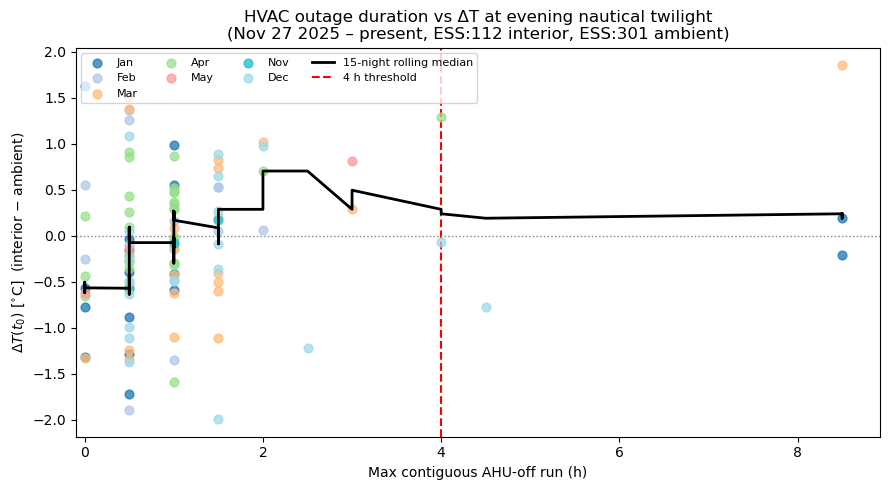

n = 111  |  Spearman r = 0.275


In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

# ── Prepare ───────────────────────────────────────────────────────────────────
_df_p = _df_out.dropna(subset=["outage_h", "dT_at_t0"]).copy()
_df_p["month"] = pd.to_datetime(_df_p["night"]).dt.month
_df_p.sort_values("outage_h", inplace=True, ignore_index=True)

# running median (window = min(15, N))
_win = min(15, len(_df_p))
_df_p["roll_med"] = _df_p["dT_at_t0"].rolling(_win, center=True, min_periods=3).median()

# colour by month
_months   = sorted(_df_p["month"].unique())
_cmap_12  = cm.get_cmap("tab20", 12)
_col_map  = {m: _cmap_12(m - 1) for m in range(1, 13)}

fig, ax = plt.subplots(figsize=(9, 5))

for m, grp in _df_p.groupby("month"):
    ax.scatter(grp["outage_h"], grp["dT_at_t0"],
               color=_col_map[m], alpha=0.75, s=40, zorder=3,
               label=pd.Timestamp(2025, m, 1).strftime("%b"))

ax.plot(_df_p["outage_h"], _df_p["roll_med"],
        color="black", lw=2, label=f"{_win}-night rolling median", zorder=4)
ax.axvline(4.0, color="red", ls="--", lw=1.5, label="4 h threshold")
ax.axhline(0.0, color="gray", ls=":", lw=1)

ax.set_xlabel("Max contiguous AHU-off run (h)")
ax.set_ylabel(r"$\Delta T(t_0)\ \mathrm{[^{\circ}C]}$  (interior − ambient)")
ax.set_title("HVAC outage duration vs ΔT at evening nautical twilight\n"
             "(Nov 27 2025 – present, ESS:112 interior, ESS:301 ambient)")
ax.legend(ncol=4, fontsize=8, loc="upper left")
ax.set_xlim(left=-0.1)
fig.tight_layout()
plt.show()
print(f"n = {len(_df_p)}  |  Spearman r = "
      f"{_df_p[['outage_h','dT_at_t0']].corr(method='spearman').iloc[0,1]:.3f}")


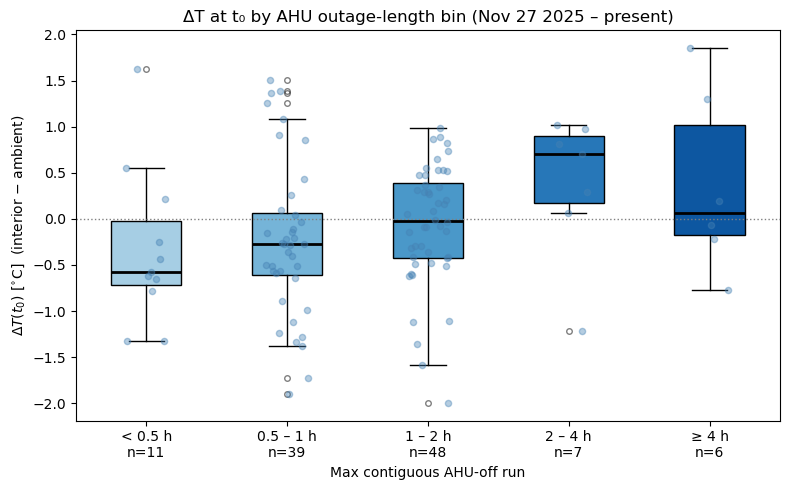

In [8]:
# ── Plot 2 — Binned box plot ──────────────────────────────────────────────────
_bins   = [0, 0.5, 1.0, 2.0, 4.0, np.inf]
_labels = ["< 0.5 h", "0.5 – 1 h", "1 – 2 h", "2 – 4 h", "≥ 4 h"]
_df_p["outage_bin"] = pd.cut(_df_p["outage_h"], bins=_bins, labels=_labels, right=False)

_box_data = [_df_p.loc[_df_p["outage_bin"] == lbl, "dT_at_t0"].dropna().values
             for lbl in _labels]
_counts   = [len(d) for d in _box_data]

fig2, ax2 = plt.subplots(figsize=(8, 5))
bp = ax2.boxplot(_box_data, patch_artist=True, notch=False, widths=0.5,
                 medianprops=dict(color="black", lw=2),
                 flierprops=dict(marker="o", markersize=4, alpha=0.5))

_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(_labels)))
for patch, c in zip(bp["boxes"], _colors):
    patch.set_facecolor(c)

# strip jitter
_rng = np.random.default_rng(0)
for i, d in enumerate(_box_data):
    jitter = _rng.uniform(-0.15, 0.15, size=len(d))
    ax2.scatter(np.full(len(d), i + 1) + jitter, d,
                color="steelblue", alpha=0.4, s=20, zorder=3)

ax2.axhline(0, color="gray", ls=":", lw=1)
ax2.set_xticks(range(1, len(_labels) + 1))
ax2.set_xticklabels([f"{l}\nn={n}" for l, n in zip(_labels, _counts)])
ax2.set_xlabel("Max contiguous AHU-off run")
ax2.set_ylabel(r"$\Delta T(t_0)\ \mathrm{[^{\circ}C]}$  (interior − ambient)")
ax2.set_title("ΔT at t₀ by AHU outage-length bin (Nov 27 2025 – present)")
fig2.tight_layout()
plt.show()


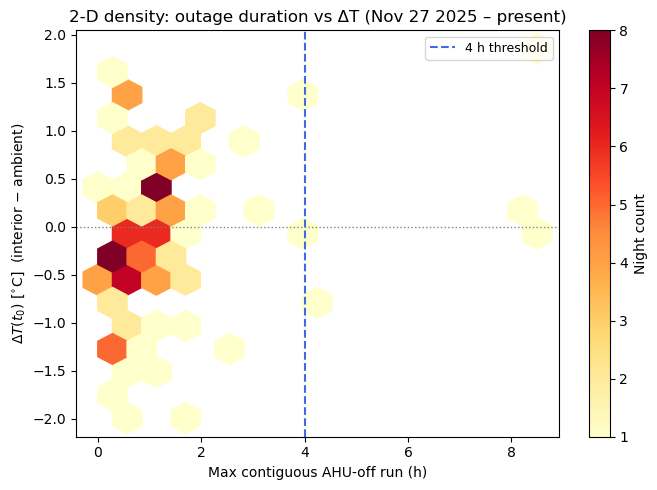

In [9]:
# ── Plot 3 — 2-D hexbin density ──────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 5))
hb = ax3.hexbin(_df_p["outage_h"], _df_p["dT_at_t0"],
                gridsize=15, cmap="YlOrRd", mincnt=1)
cb = fig3.colorbar(hb, ax=ax3, label="Night count")
ax3.axvline(4.0, color="royalblue", ls="--", lw=1.5, label="4 h threshold")
ax3.axhline(0.0, color="gray",      ls=":",  lw=1)
ax3.set_xlabel("Max contiguous AHU-off run (h)")
ax3.set_ylabel(r"$\Delta T(t_0)\ \mathrm{[^{\circ}C]}$  (interior − ambient)")
ax3.set_title("2-D density: outage duration vs ΔT (Nov 27 2025 – present)")
ax3.legend(fontsize=9)
fig3.tight_layout()
plt.show()
